manuela Ragua
Karin Guerrero

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

In [140]:
datos_pacientes = pd.read_csv("data/Datos Lab 1.csv")

In [141]:
data = datos_pacientes.copy()

- Completitud

In [142]:
((data.isnull().sum() / data.shape[0]) * 100).sort_values(ascending=False)

Diastolic BP                    5.186089
HDL (mg/dL)                     5.003051
Waist-to-Height Ratio           4.636974
Weight (kg)                     4.453935
Height (cm)                     4.148871
Age                             4.148871
Total Cholesterol (mg/dL)       4.148871
Height (m)                      3.721782
Abdominal Circumference (cm)    3.721782
Systolic BP                     3.721782
Estimated LDL (mg/dL)           3.477730
Fasting Blood Sugar (mg/dL)     3.294692
BMI                             3.233679
CVD Risk Score                  1.769372
Patient ID                      0.000000
Blood Pressure Category         0.000000
Smoking Status                  0.000000
Family History of CVD           0.000000
Physical Activity Level         0.000000
Diabetes Status                 0.000000
Date of Service                 0.000000
Blood Pressure (mmHg)           0.000000
Sex                             0.000000
CVD Risk Level                  0.000000
dtype: float64

In [143]:
nulos_obj = data['CVD Risk Score'].isna().sum()
porcentaje = (nulos_obj / data.shape[0]) * 100

print(f"Nulos en CVD Risk Score: {nulos_obj}")

Nulos en CVD Risk Score: 29


Existen 29 valores nulos para la variable CVD Risk Score. Estos valores se deben eliminar en la limpieza (objetivo)

- Unicidad

In [144]:
data.duplicated().sum()


np.int64(151)

In [145]:
dup_counts = (data['Patient ID']
              .value_counts()
              .loc[lambda s: s > 1]
              .sort_values(ascending=False))

dup_counts.head()

Patient ID
THSJ8564    3
LdMm6225    3
lqUc7918    3
ChGR7779    3
szyX1885    3
Name: count, dtype: int64

In [146]:
data.groupby('Patient ID')['Date of Service'].nunique().sort_values(ascending=False).head()

Patient ID
AEFC1294    1
iKWk5760    1
isDx5313    1
ioby2183    1
inbh2408    1
Name: Date of Service, dtype: int64

Existen registros duplicados en el dataset. Se analizo la catidad de fechas distintas por ID y se identifico que estos duplicados tienen la misma fecha de atencion, por lo que, no son consultas en fechas distintas a una misma persona si no que son registros duplicados

- Consistencia

In [147]:
data.select_dtypes(include='object').columns

Index(['Patient ID', 'Date of Service', 'Sex', 'Blood Pressure (mmHg)',
       'Smoking Status', 'Diabetes Status', 'Physical Activity Level',
       'Family History of CVD', 'Blood Pressure Category', 'CVD Risk Level'],
      dtype='object')

In [148]:
data['Sex'].value_counts()
data['Smoking Status'].value_counts()
data['Diabetes Status'].value_counts()
data['Physical Activity Level'].value_counts()
data['Family History of CVD'].value_counts()
data['CVD Risk Level'].value_counts()

CVD Risk Level
HIGH            793
INTERMEDIARY    616
LOW             230
Name: count, dtype: int64

No se encontraron variaciones, errores ni categorias duplicadas. Por tanto no se requieren ajustes

- Validez

In [149]:
data.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


In [150]:
for col in data.select_dtypes(include='number').columns:
    negativos = (data[col] < 0).sum()
    if negativos > 0:
        print(f"{col}: {negativos} valores negativos")

Total Cholesterol (mg/dL): 1 valores negativos
Estimated LDL (mg/dL): 16 valores negativos
CVD Risk Score: 9 valores negativos


Se encontraron valores negativos en variables que no deberian ser posibles, incluida la variable objetivo CVD Risk. Estos se deben tratar en la limpieza

- Eliminar Nulos

In [151]:
data = data.dropna(subset=['CVD Risk Score'])

Se eliminaron los valores faltantes en la variable objetivo CVD Risk Score, dado que en modelos no es vakido imputar la variable dependiente, ya que ello introduciria sesgo en entrenamiento y evaluacion del modelo

- Eliminar Duplicados

In [152]:
data = data.drop_duplicates()

# Verificar
data.duplicated().sum()

np.int64(0)

Se eliminaron registros duplicados para evitar sesgos de sobre-representacion de ciertos pacientes. Posteriormente se verifico que no permanecieran duplicados en el conjunto de datos


- conversion de negativos

In [153]:
for col in data.select_dtypes(include='number').columns:
    data.loc[data[col] < 0, col] = np.nan
    data[col] = data[col].fillna(data[col].mean())

# Verificación
for col in data.select_dtypes(include='number').columns:
    negativos = (data[col] < 0).sum()
    if negativos > 0:
        print(f"{col}: {negativos} valores negativos")

Se identificaron valores negativos en variables donde esos valores no son posibles. Se decidio reemplazar primero por valores faltantes (NaN) y luego se les asigno la media de cada variable. Este procedimiento evita distorsionar la distribucion de los datos y que el calculo del promedio no incluya valores erroneos

 ## 4. Partición de los datos.

Para este caso se va a definir CVD Risk Score como la variable objetivo y las demas como predictoras. No se incluyen las identificadoras, ni el CVD Risk Level poruq e se deriva de la predictora

In [154]:
target = 'CVD Risk Score'
X = data.drop(columns=[
    target,
    'CVD Risk Level',
    'Patient ID',
    'Date of Service',
    'Blood Pressure (mmHg)'
])

y = data[target]

- Verificar la separacion

In [155]:
X

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL)
0,M,44.000000,114.300000,1.72000,38.600000,100.000,228.0,77.0,91.0,Y,Y,High,N,172.000,0.581,112.0,83.000000,Hypertension Stage 1,121.0
1,F,57.000000,92.923000,1.84200,33.116000,106.315,158.0,71.0,76.0,N,Y,High,Y,184.172,0.577,101.0,91.000000,Hypertension Stage 2,57.0
2,F,46.938024,73.400000,1.65000,27.000000,78.100,135.0,60.0,150.0,N,N,High,N,165.000,0.473,90.0,74.000000,Normal,45.0
3,F,35.000000,113.300000,1.78000,35.800000,79.600,158.0,34.0,111.0,Y,N,Moderate,Y,178.000,0.447,92.0,89.000000,Hypertension Stage 1,94.0
4,F,48.000000,102.200000,1.75000,33.400000,106.700,207.0,49.0,147.0,Y,Y,Low,Y,175.000,0.610,121.0,68.000000,Elevated,128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,M,40.000000,120.000000,1.75748,35.400000,100.900,223.0,62.0,84.0,Y,Y,Moderate,Y,184.000,0.548,94.0,68.000000,Normal,131.0
1634,F,35.000000,77.600000,1.78000,24.500000,84.600,143.0,76.0,108.0,N,N,Low,N,178.000,0.475,124.0,90.000000,Hypertension Stage 2,37.0
1635,F,35.000000,92.005000,1.72600,28.512194,98.692,156.0,80.0,80.0,N,Y,High,N,172.602,0.572,95.0,111.000000,Hypertension Stage 2,46.0
1637,M,49.000000,85.953232,1.63000,23.100000,93.800,191.0,79.0,117.0,Y,Y,Moderate,Y,163.000,0.575,144.0,82.900639,Hypertension Stage 2,82.0


In [156]:
y

0       19.880
1       16.833
2       12.600
3       14.920
4       18.870
         ...  
1632    18.240
1634    13.960
1635    14.316
1637    17.640
1638    15.060
Name: CVD Risk Score, Length: 1460, dtype: float64

- division train_set
Se utilizara el 80% de datos como entrenamiento para el modelo y un 20% para la evaluzacion.


In [157]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=1)


tamaños de los conjuntos


In [158]:
X_train.shape, y_train.shape

((1168, 19), (1168,))

In [159]:
X_test.shape, y_test.shape

((292, 19), (292,))

## 5.1 Construcción del pipeline

- Identificar variables numericas y categoricas

In [160]:
var_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
var_cat = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", var_num)
print("Categóricas:", var_cat)


Numéricas: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']



- Transformacion de var numericas


In [161]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)


- Transformacion var categoricas


In [162]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

- combinar

In [163]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, var_num),
        ("cat", categorical_transformer, var_cat),
    ]
)

- Pipeline con regresion

In [164]:
pipeline_regresion = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("regresion", LinearRegression()),
])

- estructura del pipeline:

In [165]:
from sklearn import set_config
set_config(display="diagram")

In [166]:
pipeline_regresion

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Weight (kg)',
                                                   'Height (m)', 'BMI',
                                                   'Abdominal Circumference '
                                                   '(cm)',
                                                   'Total Cholesterol (mg/dL)',
                                                   'HDL (mg/dL)',
                                                   'Fasting Blood Sugar '
                                                   '(mg/dL)',
                                                   'Height (cm)',
                                                   'Waist-to-Height Ratio',
                                                   'Systolic BP',
                                                   'Diastolic BP',
                                                   'Estimated LDL (mg/dL)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Smoking Status',
                                                   'Diabetes Status',
                                                   'Physical Activity Level',
                                                   'Family History of CVD',
                                                   'Blood Pressure '
                                                   'Category'])])),
                ('regresion', LinearRegression())])

In [167]:
Xt_train = pipeline_regresion.named_steps["preprocesamiento"].fit_transform(X_train)


In [168]:
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

El primer modelo se construyo usando todas las variables disponibles tras la limpieza y el preprocesamiento. Para ello, se implemento un Pipeline que integra el escalamiento de variables numericas y el entrenamiento de un modelo de regresion lineal

Se incluyeron todas las variables predictoras para establecer una base, evaluar la capacidad de el conjunto completo de explicacion e identificar relevancias de los predictores

## 6.1 Entrenamiento del modelo 1 de regresión lineal.

- entrenar modelo

In [173]:
Modelo = LinearRegression()

In [174]:
Modelo.fit(Xt_train_df, y_train)

LinearRegression()

- predicciones

In [175]:
y_train_pred = Modelo.predict(Xt_train_df)

### Validación del modelo 1


In [176]:
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE:", mae_train)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE:", rmse_train)
r2_train = r2_score(y_train, y_train_pred)
print("R^2:", r2_train)

MAE: 3.3677548468405187
RMSE: 9.990131518845399
R^2: 0.0656643776213306


En el entrenamiento, el modelo dio un MAE de 3.37 y un RMSE de 9.99, lo que indica que el error promedio absoluto es moderado.

El R^2 obtenido fue de 0.0657, lo que implica que el modelo explica el 6.6% de la variabilidad del riesgo cardiovascular. Aunque el desempeño es superior al del conjunto de prueba, la capacidad explicativa del modelo sigue siendo limitada.

## 7. Estimación de la capacidad de generalización del modelo.


Ahora, utilizamos el modelo para predecir sobre el conjunto de prueba:

In [177]:
Xt_test = pipeline_regresion.named_steps["preprocesamiento"].transform(X_test)

In [178]:
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
Xt_test_df = pd.DataFrame(
    Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test,
    columns=feature_names,
    index=X_test.index
)

In [179]:
y_test_pred = Modelo.predict(Xt_test_df)

### Validación del modelo

Como se comporta el modelo ante nuevos datos:

In [180]:
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE  test :", mae_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
print("RMSE test :", rmse_test)
r2_test = r2_score(y_test, y_test_pred)
print("R²   test :", r2_test)

MAE  test : 3.6985120906822915
RMSE test : 11.347073837238861
R²   test : 0.012118734042926627


Ell modelo presento para las pruebas un MAE de 3.70 y un RMSE de 11.35, lo que indica que las predicciones se desvian un poco del valor real, aunque existen algunos errores de mayor magnitud.

El R^2 obtenido fue de 0.0121, lo que significa una capacidad explicativa limitada, ya que el modelo logra explicar apenas el 1.21% de la variabilidad del riesgo cardiovascular.

Los resultados sugieren que la regresion no captura la complejidad del fenomeno estudiado.

El Modelo 1 tiene mejor desempeño en MAE y R2, por lo que se escoge como modelo final.

## 10. Variables - Modelo 1 (final)

In [188]:
coef_df = pd.DataFrame({
    "Variable": Xt_train_df.columns,
    "Coeficiente": Modelo.coef_
})

coef_df["Abs_coef"] = np.abs(coef_df["Coeficiente"])

coef_df.sort_values("Abs_coef", ascending=False).head(10)

,Variable,Coeficiente,Abs_coef
15,cat__Diabetes Status_Y,3.414229,3.414229
3,num__BMI,1.552729,1.552729
23,cat__Blood Pressure Category_Normal,-1.274750,1.274750
18,cat__Physical Activity Level_Moderate,0.726825,0.726825
10,num__Systolic BP,0.710122,0.710122
5,num__Total Cholesterol (mg/dL),0.609114,0.609114
17,cat__Physical Activity Level_Low,-0.601693,0.601693
21,cat__Blood Pressure Category_Hypertension Stage 1,0.573878,0.573878
1,num__Weight (kg),-0.560253,0.560253
9,num__Waist-to-Height Ratio,0.544615,0.544615


Las variables que tienen mayor impacto fueron Diabetes Status, BMI y categorias de presion arterial. Por tanto podemos decir que la presencia de diabetes incrementa  el riesgo cardiovascular y tambien un mayor indice de masa corporal y mayores niveles de presion sistolica se asocian con un incremento en el riesgo estimado.

Dado que las variables numericas fueron estandarizadas, los coeficientes pueden compararse directamente en magnitud relativa.

Sin embargo, pese a la coherencia clinica de los resultados, el modelo presenta un R² bajo, lo que indica que la capacidad explicativa es limitada.

## 11. Verificación de supuestos


In [189]:
Modelo = LinearRegression()
Modelo.fit(Xt_train_df, y_train)
y_train_pred = Modelo.predict(Xt_train_df)
print("Intercepto:", Modelo.intercept_)

Intercepto: 16.482142718860665


In [190]:
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": Modelo.coef_
})
coef_df

,Variable,Coeficiente
0,Age,-0.073894
1,Weight (kg),-0.560253
2,Height (m),0.379743
3,BMI,1.552729
4,Abdominal Circumference (cm),-0.306696
5,Total Cholesterol (mg/dL),0.609114
6,HDL (mg/dL),-0.393714
7,Fasting Blood Sugar (mg/dL),0.036522
8,Height (cm),0.024618
9,Waist-to-Height Ratio,0.544615


### Multicolinealidad

In [191]:
X_vif = Xt_train_df.select_dtypes(include="number").copy()
clean_columns = (
    X_vif.columns
         .str.replace("^num__", "", regex=True)
         .str.replace("^cat__", "", regex=True)
)
vif_values = []
with np.errstate(divide="ignore", invalid="ignore"):
    for i in range(X_vif.shape[1]):
        vif = variance_inflation_factor(X_vif.values, i)
        vif_values.append(vif)

vif_data = pd.DataFrame({
    "Variable": clean_columns,
    "VIF": vif_values
})
print(vif_data)

                                        Variable       VIF
0                                            Age  1.038050
1                                    Weight (kg)  1.484810
2                                     Height (m)  4.994280
3                                            BMI  1.522108
4                   Abdominal Circumference (cm)  3.658334
5                      Total Cholesterol (mg/dL)  3.240781
6                                    HDL (mg/dL)  1.169086
7                    Fasting Blood Sugar (mg/dL)  1.038167
8                                    Height (cm)  5.018435
9                          Waist-to-Height Ratio  4.290843
10                                   Systolic BP  1.362058
11                                  Diastolic BP  1.562694
12                         Estimated LDL (mg/dL)  3.298277
13                                         Sex_M  1.009404
14                              Smoking Status_Y  1.014327
15                             Diabetes Status_Y  1.0259

### Normalidad de los errores



In [192]:
residuales = np.array(y_train - y_train_pred)

estat, p_shapiro = shapiro(residuales)
print("Shapiro-Wilk p-value:", p_shapiro)

Shapiro-Wilk p-value: 1.5938118179306794e-54


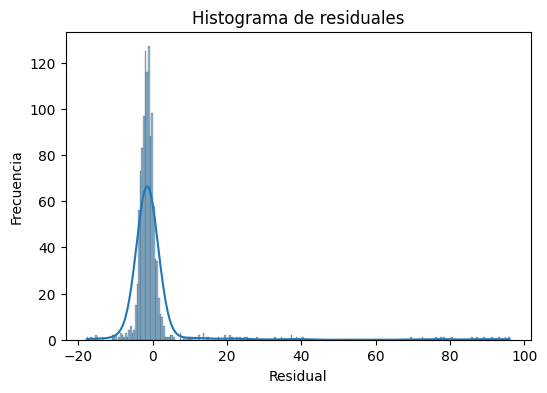

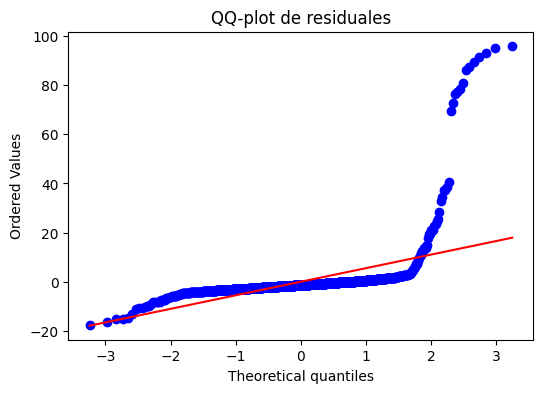

In [193]:
plt.figure(figsize=(6, 4))
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6, 4))
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

### Homecedasticidad


In [194]:
X_num = Xt_train_df.select_dtypes(include="number").copy()
mask = np.isfinite(X_num).all(axis=1)
X_num_clean = X_num[mask]
resid_clean = residuales[mask]
X_num_const = sm.add_constant(X_num_clean)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid_clean, X_num_const)

print("Estadístico Breusch-Pagan:", bp_stat)
print("p-value Breusch-Pagan   :", bp_pvalue)

Estadístico Breusch-Pagan: 27.634232548069335
p-value Breusch-Pagan   : 0.27576904711173883


### Independencia de los errores
  

In [195]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.9236917088058756


### Gráficas para ver de manera visual la homocedasticidad e independencia de los residuos

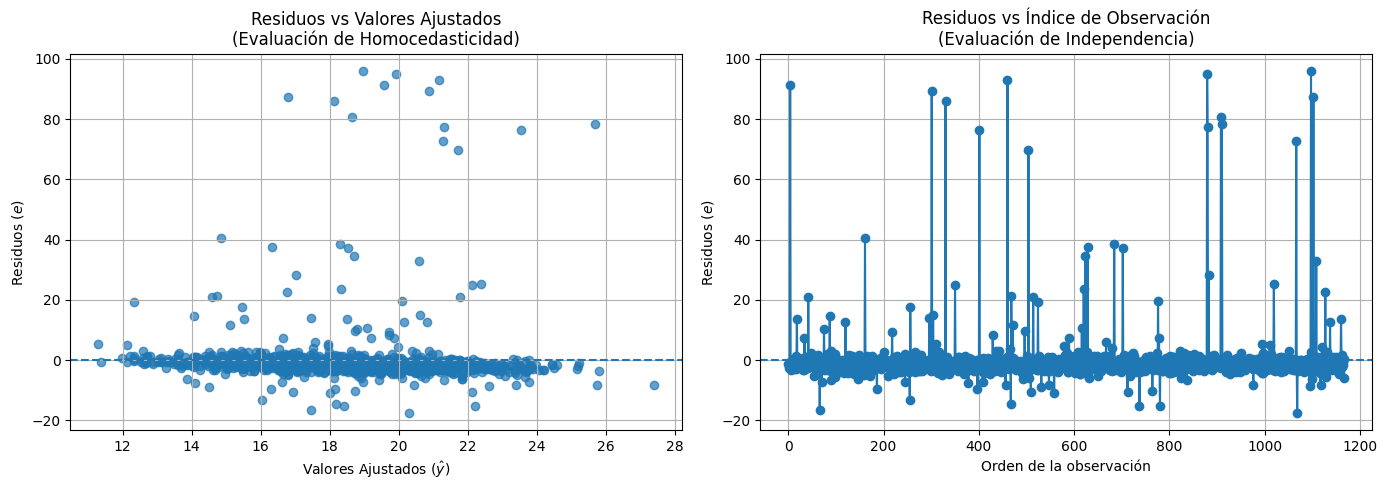

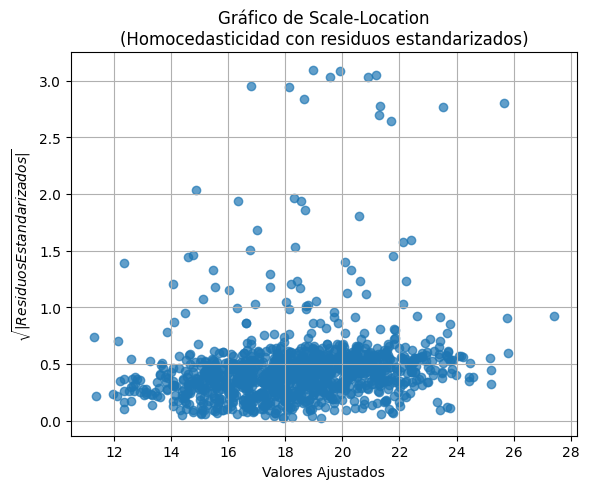

In [196]:

X_sm = Xt_train_df.copy()
X_sm = sm.add_constant(X_sm)
y_sm = y_train

model = sm.OLS(y_sm, X_sm).fit()

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.title('Residuos vs Valores Ajustados\n(Evaluación de Homocedasticidad)')
plt.xlabel('Valores Ajustados ($\hat{y}$)')
plt.ylabel('Residuos ($e$)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(len(residuals)), residuals, marker='o', linestyle='-')
plt.axhline(y=0, linestyle='--')
plt.title('Residuos vs Índice de Observación\n(Evaluación de Independencia)')
plt.xlabel('Orden de la observación')
plt.ylabel('Residuos ($e$)')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))

standardized_residuals = model.get_influence().resid_studentized_internal

plt.scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.7)

plt.title('Gráfico de Scale-Location\n(Homocedasticidad con residuos estandarizados)')
plt.xlabel('Valores Ajustados')
plt.ylabel('$\sqrt{|Residuos Estandarizados|}$')
plt.grid(True)

plt.tight_layout()
plt.show()




### Linealidad


In [197]:
X_sm = sm.add_constant(Xt_train_df)
modelo_sm = sm.OLS(y_train, X_sm).fit()

rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

print("Estadístico Rainbow:", rainbow_stat)
print("p-value Rainbow    :", rainbow_pvalue)

Estadístico Rainbow: 1.4433912511874814
p-value Rainbow    : 6.222420773044918e-06


## 12. Analisis de resultados

1. cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

    El mejor modelo fue el 1 , ya que presento el mayor R^2 en el conjunto de prueba. Los coeficientes mas relevantes fueron:
        
        Diabetes Status: impacto positivo alto
        BMI: impacto positivo
        Systolic BP: impacto positivo
        Total Cholesterol: impacto positivo
        Blood Pressure Category_Normal: impacto negativo
    Dado que las variables numericas fueron estandarizadas, los coeficientes pueden compararse directamente en magnitud. En general la presencia de diabetes, mayor IMC, mayor presion sistolica y mayor colesterol aumentan el riesgo cardiovascular estimado, mientras que tener presion arterial normal lo reduce

2. cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

    El Modelo 1 ofrece el mejor rendimiento en el test, ya que obtuvo el mayor R^2= 0.0121 frente al Modelo 2= 0.0026

    Las metricas se interpretan asi:

    MAE= 3.7: el error promedio absoluto es moderado.
    RMSE= 11.3: existen algunos errores grandes que incrementan el error cuadratico.
    R^2= 0.01: → el modelo explica el 1% de la variabilidad del riesgo cardiovascular.

    Aunque el modelo logra capturar algunas relaciones coherentes, su capacidad explicativa es limitada y el fenomeno no se ajusta bien a una relacion lineal simple

3. cuáles variables fueron seleccionadas con el modelo seleccionado? ¿Qué interpretación de cara al problema puedes dar?

    El modelo incluyo variables como:
    Diabetes Status, BMI, Systolic BP, Total Cholesterol, Categorias de presn arterial y nivel de actividad fisica

    Estas variables corresponden a factores de riesgo cardiovascular. Esto confirma que el modelo identifica patrones coherentes.

    Desde el punto de vista practico, estos resultados pueden apoyar la toma de decisiones preventivas, priorizando el control de diabetes, peso corporal, presion arterial y colesterol para reducir el riesgo.

4. cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

    La regresion lineal se representa como:

    ŷ = β₀ + β₁X₁ + β₂X₂ + … + βₙXₙ ; ŷ: riesgo cardiovascular estimado, β₀: intercepto, βᵢ: coeficientes, Xᵢ: variables predictoras.

    El metodo utilizado fue minimos cuadrados ordinarios, paraminimizar la suma de los errores al cuadrado:
    Σ (yᵢ − ŷᵢ)²

    En forma matricial, la solución se obtiene mediante:

    β = (XᵀX)⁻¹ Xᵀy

5. qué tipos de sesgo podrían afectar los resultados y por qué?

    Uno de los posibles es el sesgo de seleccion, que ocurre si la muestra no representa adecuadamente a la poblacion, lo que limita la capacidad de generalizacion del modelo.

    Otro posible es el sesgo por variables omitidas. El riesgo cardiovascular depende de factores adicionales como genetica, alimentacien, estres o medicacion. Estas variables no estan incluidas en el modelo, por lo que su capacidad explicativa disminuye, lo que puede explicar el bajo R² obtenido.